### Overview

#### 1. 序列模型
Lecture 2中的计算机视觉领域的模型是处理空间信息，那么序列模型处理的是时间信息
- 音频数据：音频本质上是随时间变化的空气压力的震动
- 文本数据：单词或词元按照特定顺序排列才有意义
- 时间序列：股票价格或传感器数据

#### 2.统计工具
- 在时间t观察到$x_t$,那么得到T个不独立的随机变量$（x_1,x_2,...,x_T）->p(x)$
- 使用条件概率展开为$p(x_t|x_{t-1},x_{t-2},...,x_1)p(x_{t-1}|x_{t-2},x_{t-3},...,x_1)...p(x_1)$

#### 3.自回归模型：对见过的数据建模
- 自回归模型假设时间序列的当前值依赖于之前的值
- 假设$x_t$是时间序列的当前值，那么$p(x_t|x_{t-1},x_{t-2},...,x_1)$

#### 4.马尔科夫假设
- 当前数据只跟m个过去数据点相关
- $p(x_t|x_{t-1},x_{t-2},...,x_1)=p(x_t|x_{t-m},x_{t-1})=p(x_t|f(x_{t-m}...x_{t-1}))$

#### 5.潜变量模型
- 引入潜变量$h_t$来表示过去信息$h_t = f(x_1,...,x_{(t-1)})$
- $x_t = p(x_t|h_t)$


In [1]:
import torch
from torch import nn
from d2l import torch as d2l

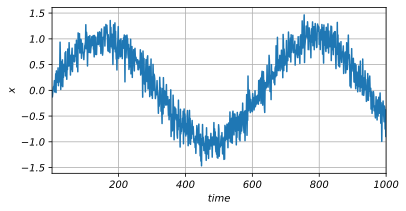

In [2]:
T=1000
time=torch.arange(1,T+1,dtype=torch.float32)
x=torch.sin(0.01*time) + torch.normal(0,0.2,(T,))
d2l.plot(time,x,'time','x',xlim=[1,T],figsize=(6,3))

In [3]:
#马尔可夫假设
tau=4
features=torch.zeros((T-tau,tau))#样本数减去特征数
for i in range(tau):
    features[:,i]=x[i:T-tau+i]#训练数据
labels=x[tau:].reshape(-1,1)

batch_size,n_train=16,600
train_iter=d2l.load_array((features[:n_train],labels[:n_train]),batch_size,is_train=True)


In [4]:
#两个全连接层的多层感知机
def init_weights(m):
    if type(m)==nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net=nn.Sequential(
        nn.Linear(4,10),
        nn.ReLU(),
        nn.Linear(10,1)
    )
    net.apply(init_weights)
    return net

loss=nn.MSELoss()


In [5]:
def train(net,train_iter,loss,epohcs,learning_rate):
    trainer=torch.optim.Adam(net.parameters(),lr=learning_rate)
    for epoch in range(epohcs):
        for x,y in train_iter:
            l=loss(net(x),y)
            l.backward()
            trainer.step()
        print(f'epoch{epoch+1},loss{d2l.evaluate_loss(net,train_iter,loss)}')
net=get_net()
train(net,train_iter,loss,10,0.01)

epoch1,loss0.3934916657836814
epoch2,loss0.4596897547966556
epoch3,loss0.34612861079605
epoch4,loss5.537642212290513
epoch5,loss22.06380793922826
epoch6,loss7.346197862374155
epoch7,loss1.0403288791054173
epoch8,loss3.0448049542151
epoch9,loss2.6037516499820508
epoch10,loss7.4049631592474485


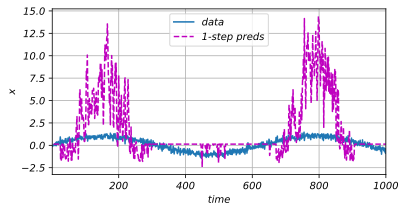

In [6]:
#预测下一个
onestep_preds=net(features)
d2l.plot(
    [time,time[tau:]],
    [x.detach().numpy(),onestep_preds.detach().numpy()],
    'time','x',legend=['data','1-step preds'],xlim=[1,T],figsize=(6,3)
) 

In [7]:
#进行多步预测
multistep_preds = torch.zeros_like(x)  # 更稳妥的初始化方式，避免设备/类型不匹配
multistep_preds[:tau] = x[:tau]  # 前tau个值用原始数据初始化

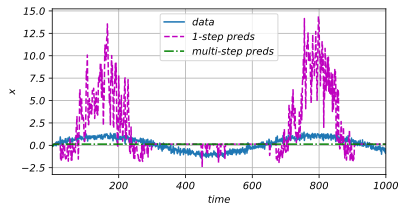

In [8]:
# 多步预测循环
for i in range(tau, T):
    multistep_preds[i] = net(multistep_preds[i-tau:i].reshape(1, -1)).item()  # 取出标量值

# 可视化（修复括号不匹配和参数格式问题）
d2l.plot(
    [time, time[tau:], time],  # 三个序列的x轴坐标（数据、1步预测、多步预测）
    [x.detach().numpy(), 
     onestep_preds.detach().numpy(), 
     multistep_preds.detach().numpy()],  # 三个序列的y轴数据
    'time', 'x',  # x轴和y轴标签
    legend=['data', '1-step preds', 'multi-step preds'],  # 图例
    xlim=[1, T],  # x轴范围
    figsize=(6, 3)
)  

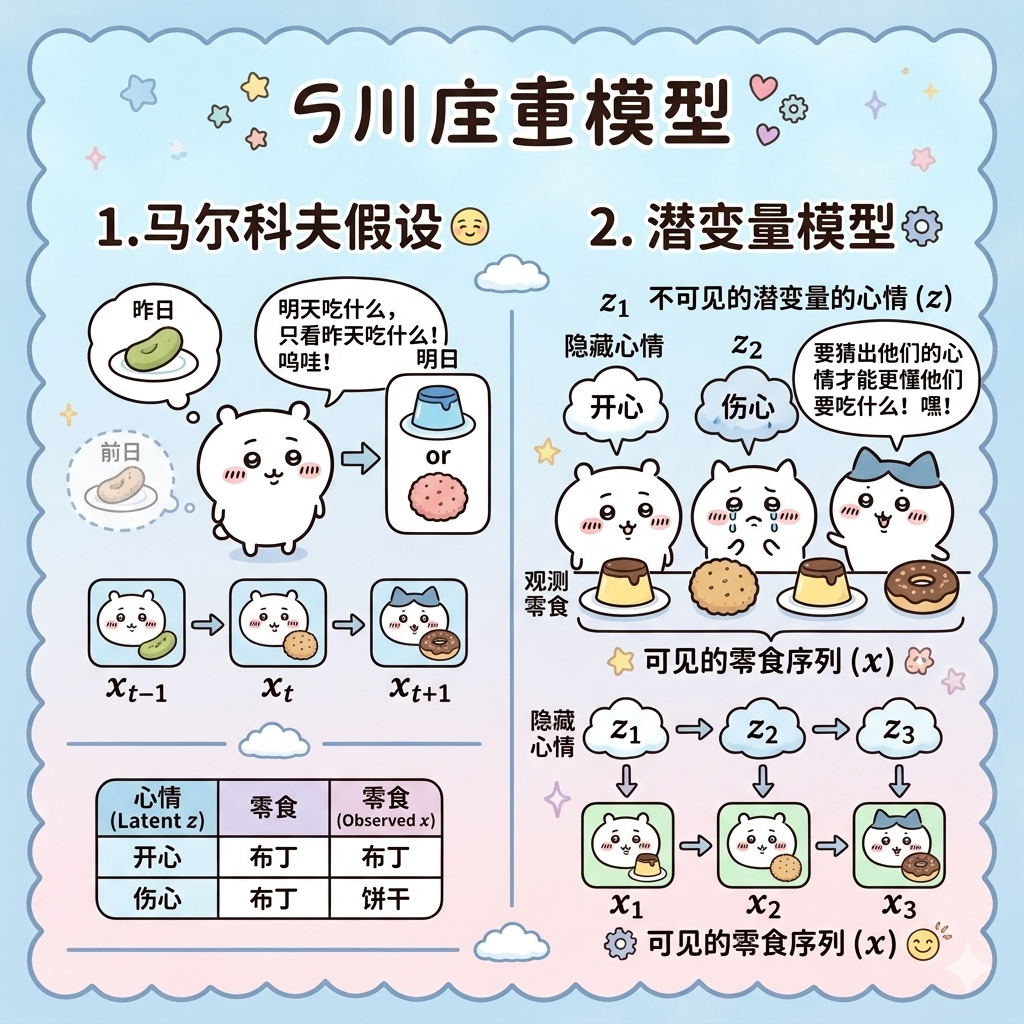